
# Lab 4: FDM-diffusion

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
3. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
4. Do a gif for the temperature in time (bonus!)

Para resolver el problema 2D de un plato conductor de aluminio: $a = 20\text{ mm}$, $b = 10\text{ mm}$, $D = 84\text{ mm}^2/\text{s}$), derivamos la solución analitica excata y se construye un scrip de pyhton con el método de diferencias finitas.

La solución  analitica es:

$\nabla^2 T = 0$ con condiciones de frontera
$T(0,y)=T(a,y)=T(x,0)=0^\circ\text{C}$ and $T(x,b) = 100\sin\left(\frac{3\pi x}{a}\right)$,

de donde, 


$$T_{\text{analitica}}(x,y) = 100 \frac{\sinh\left(\frac{3\pi y}{a}\right)}{\sinh\left(\frac{3\pi b}{a}\right)} \sin\left(\frac{3\pi x}{a}\right)$$

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter


a, b = 20.0, 10.0        
D = 84.0                   
dx = dy = 0.1              

nx = int(a / dx) + 1
ny = int(b / dy) + 1

x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)
X, Y = np.meshgrid(x, y, indexing='ij')


f_x = 100.0 * np.sin(3.0 * np.pi * x / a)


In [ ]:
#1 Use FDM to solve the static solution

T_static = np.zeros((nx, ny))
T_static[:, -1] = f_x 

tol = 1e-6
diff = 1.0
while diff > tol:
    T_old = T_static.copy()
    T_static[1:-1, 1:-1] = 0.25 * (T_old[2:, 1:-1] + T_old[:-2, 1:-1] + T_old[1:-1, 2:] + T_old[1:-1, :-2])
    diff = np.max(np.abs(T_static - T_old))

Error máximo absoluto (FDM vs Analytical): 0.0060 °C


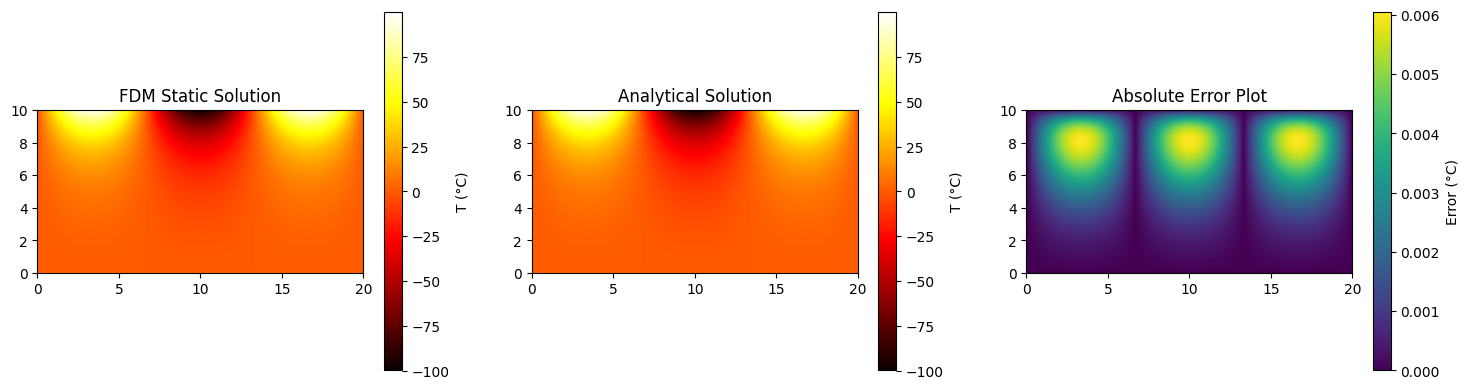

In [ ]:
#2 Compare the static solution with the analytical one.

T_analytical = 100.0 * (np.sinh(3 * np.pi * Y / a) / np.sinh(3 * np.pi * b / a)) * np.sin(3 * np.pi * X / a)
max_error = np.max(np.abs(T_static - T_analytical))
print(f"Error máximo absoluto (FDM vs Analytical): {max_error:.4f} °C")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(T_static.T, origin='lower', extent=[0, a, 0, b], cmap='hot')
axes[0].set_title("FDM Static Solution")
fig.colorbar(im0, ax=axes[0], label="T (°C)")

im1 = axes[1].imshow(T_analytical.T, origin='lower', extent=[0, a, 0, b], cmap='hot')
axes[1].set_title("Analytical Solution")
fig.colorbar(im1, ax=axes[1], label="T (°C)")

im2 = axes[2].imshow(np.abs(T_static - T_analytical).T, origin='lower', extent=[0, a, 0, b], cmap='viridis')
axes[2].set_title("Absolute Error Plot")
fig.colorbar(im2, ax=axes[2], label="Error (°C)")
plt.tight_layout()
plt.show()

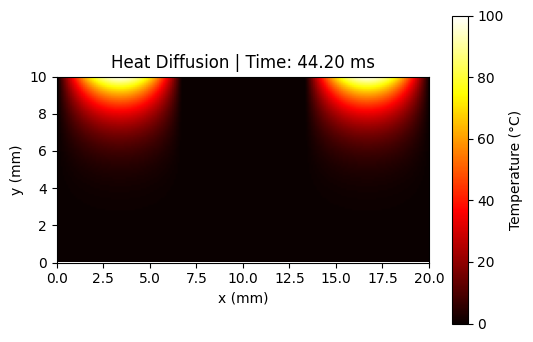

In [14]:
#3 Use FDM to found the temperature, i.e., solve the diffusion equation for some times.
#4 Do a gif for the temperature in time (bonus!) 

dx2, dy2 = dx**2, dy**2
dt = (dx2 * dy2)/(2 * D * (dx2 + dy2))  

T_time = np.zeros((nx, ny))
T_time[:, -1] = f_x

n_steps = 1500
save_every = 15
history = []

for step in range(n_steps):
    if step % save_every == 0:
        history.append((step * dt * 1000, T_time.copy()))
    
    T_next = T_time.copy()
    T_next[1:-1, 1:-1] = T_time[1:-1, 1:-1] + D * dt * (
    (T_time[2:, 1:-1] - 2 * T_time[1:-1, 1:-1] + T_time[:-2, 1:-1]) / dx2 + (T_time[1:-1, 2:] - 2 * T_time[1:-1, 1:-1] + T_time[1:-1, :-2]) / dy2)
   
    T_next[0, :] = 0.0
    T_next[-1, :] = 0.0
    T_next[:, 0] = 0.0
    T_next[:, -1] = f_x
    T_time = T_next

fig_anim, ax_anim = plt.subplots(figsize=(6, 4))
im_anim = ax_anim.imshow(history[0][1].T, origin='lower', extent=[0, a, 0, b],
                         cmap='hot', vmin=0, vmax=100)
cbar = fig_anim.colorbar(im_anim, ax=ax_anim)
cbar.set_label("Temperature (°C)")
title_text = ax_anim.set_title(f"Time: {history[0][0]:.2f} ms")
ax_anim.set_xlabel("x (mm)")
ax_anim.set_ylabel("y (mm)")

def update(frame):
    t_ms, T_grid = history[frame]
    im_anim.set_data(T_grid.T)
    title_text.set_text(f"Heat Diffusion | Time: {t_ms:.2f} ms")
    return im_anim, title_text

anim = FuncAnimation(fig_anim, update, frames=len(history), interval=50, blit=True)
anim.save("heat_diffusion.gif", writer=PillowWriter(fps=20))
plt.show()
